In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import sys
import re
import json
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import classification_report, confusion_matrix
from scipy import signal
import ddddocr
import torch
from torchvision.models import resnet18, ResNet18_Weights
from copy import copy
import pyautogui
from datetime import datetime
import time
from tqdm import tqdm
from torch import nn
import torch.nn.functional as F
import math
from scipy.ndimage import median_filter

In [2]:
pf = pd.DataFrame(os.listdir(os.path.join("source", "data")), columns=["filename"])
pf

,filename
0,btn_gift.png
1,frame.jpg
2,frame2.jpg
3,frame3.jpg
4,main.png
5,main2.png
6,page.png
7,receive.png
8,side.png
9,side2.png


---
# __图像去噪__

### __直方图均衡化__
通过对像素进行线性放缩来让图像更好，如果像素比较集中，放大一下间距可以让对比度更高

### __修改亮度、对比度__
通过修改对比度也可以让图片有更好的效果，一般的过暗的图像可以使用这种方法来增强一下，有很多处理方案

### __均值滤波__
所有 $W_i = \frac{1}{N^2} $

$W = \begin{bmatrix}
\frac{1}{N^2} & \frac{1}{N^2} & \frac{1}{N^2} \\
\frac{1}{N^2} & \frac{1}{N^2} & \frac{1}{N^2} \\
\frac{1}{N^2} & \frac{1}{N^2} & \frac{1}{N^2} \\
\end{bmatrix} $ 

### __高斯滤波__
用带有位置的高斯函数去计算每一个 $W_i$ , 具体详见 https://www.cnblogs.com/wangguchangqing/p/6407717.html

具体公式: $G(x,y) = \frac{1}{2\pi\sigma}e^{-\frac{x^2+y^2}{2\sigma^2}}$

举个例子, $5*5$ 的高斯卷积核 $G = \begin{bmatrix}
0.002969 & 0.013306 & 0.021938 & 0.013306 & 0.002969 \\
0.013306 & 0.059634 & 0.098320 & 0.059634 & 0.013306 \\
0.021938 & 0.098320 & 0.162103 & 0.098320 & 0.21938 \\
0.013306 & 0.059634 & 0.098320 & 0.059634 & 0.013306 \\
0.002969 & 0.013306 & 0.021938 & 0.013306 & 0.002969 \\
\end{bmatrix} $

### __中值滤波__
拿出来中值 (有效的抑制椒盐噪声), 基于统计的

### __双边滤波__
考虑欧氏距离和辐射差异的滤波算法, 具体详见 https://blog.csdn.net/piaoxuezhong/article/details/78302920

他在高斯滤波的基础上乘了一个差值矩阵, 举个例子 $B = \begin{bmatrix}
0.002969 & 0.013306 & 0.021938 & 0.013306 & 0.002969 \\
0.013306 & 0.059634 & 0.098320 & 0.059634 & 0.013306 \\
0.021938 & 0.098320 & 0.162103 & 0.098320 & 0.21938 \\
0.013306 & 0.059634 & 0.098320 & 0.059634 & 0.013306 \\
0.002969 & 0.013306 & 0.021938 & 0.013306 & 0.002969 \\
\end{bmatrix} \cdot G(|(\begin{bmatrix}
I_{1,1} & I_{1,2} & I_{1,3} & I_{1,4} & I_{1,5} \\
I_{2,1} & I_{2,2} & I_{2,3} & I_{2,4} & I_{2,5} \\
I_{3,1} & I_{3,2} & I_{3,3} & I_{3,4} & I_{3,5} \\
I_{4,1} & I_{4,2} & I_{4,3} & I_{4,4} & I_{4,5} \\
I_{5,1} & I_{5,2} & I_{5,3} & I_{5,4} & I_{5,5} \\
\end{bmatrix} - I_{3,3})|)$

### __傅里叶滤波__
通过时域和频域的转换, 来确定我们要过滤掉一些不常见的峰

### __小波滤波__
将信号分解成不同尺度和频带的小波系数来确定我们要怎么过滤像素

---
# __边缘检测__

### __滤波算子__
一阶梯度算子: Roberts算子, Prewitt算子, Sobel算子, Scharr算子, Krisch 算子, Robinson 算子

二阶梯度算子: Laplace算子

其他方法算子: Canny算子

### __Roberts算子__
https://zhuanlan.zhihu.com/p/266361551

$G_1 = \begin{bmatrix}
1 & 0 \\
0 & -1 \\
\end{bmatrix} $ 
$G_2 = \begin{bmatrix}
1 & 0 \\
0 & -1 \\
\end{bmatrix} $

$g(x,y) = \sqrt{\sum_{i=1}^{2}||f(x,y) * G_i||}$

这是万恶之源, 鼻祖级别的

### __Prewitt算子__
https://zhuanlan.zhihu.com/p/266180689

$G_1 = \begin{bmatrix}
1 & 1 & 1 \\
0 & 0 & 0 \\
-1 & -1 & -1 \\
\end{bmatrix} $ 
$G_2 = \begin{bmatrix}
-1 & 0 & 1 \\
-1 & 0 & 1 \\
-1 & 0 & 1 \\
\end{bmatrix} $
$G_3 = \begin{bmatrix}
0 & 1 & 1 \\
-1 & 0 & 1 \\
-1 & -1 & 0 \\
\end{bmatrix} $ 
$G_4 = \begin{bmatrix}
-1 & -1 & 0 \\
-1 & 0 & 1 \\
0 & 1 & 1 \\
\end{bmatrix} $

$g(x,y) = \sqrt{\sum_{i=1}^{4}||f(x,y) * G_i||}$

### __Sobel算子__
https://zhuanlan.zhihu.com/p/265676987

$G_1 = \begin{bmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1 \\
\end{bmatrix} $ 
$G_2 = \begin{bmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1 \\
\end{bmatrix} $

$g(x,y) = \sqrt{\sum_{i=1}^{2}||f(x,y) * G_i||}$

### __Scharr算子__
https://zhuanlan.zhihu.com/p/265676987

$G_1 = \begin{bmatrix}
-3 & 0 & 3 \\
-10 & 0 & 10 \\
-3 & 0 & 3 \\
\end{bmatrix} $ 
$G_2 = \begin{bmatrix}
-3 & -10 & -3 \\
0 & 0 & 0 \\
3 & 10 & 3 \\
\end{bmatrix} $

$g(x,y) = \sqrt{\sum_{i=1}^{2}||f(x,y) * G_i||}$

不难看出也就这样了, 后面两个也都是修改参数的类似方法, 在这里就不介绍了

### __Laplace算子__
https://zhuanlan.zhihu.com/p/265915856

连续函数里 $f'(t) = \lim^{}_{x \rightarrow t} \frac{f(x)-f(t)}{x-t}$

咱们的图像的函数不是连续的，他在 $R^2$ 空间内, 映射到一个  $R^2$ 空间

根据他的写法: 

基础算子为 $f''(x) = 
G_1 = \begin{bmatrix}
0 & 1 & 0 \\
1 & -4 & 1 \\
0 & 1 & 0 \\
\end{bmatrix}
$

衍生算子为 $f''(x) = 
G_1 = \begin{bmatrix}
1 & 1 & 1 \\
1 & -8 & 1 \\
1 & 1 & 1 \\
\end{bmatrix}
$

边缘检测使用 $g(x,y) = f(x,y) * G_1$

图像锐化（增加边缘清晰度）使用 $g(x,y) = f(x,y) * (
\begin{bmatrix}
1 & 1 & 1 \\
1 & 1 & 1 \\
1 & 1 & 1 \\
\end{bmatrix} + G_2)$

### __Canny算子__
https://zhuanlan.zhihu.com/p/99959996

基于Canny算子的边缘检测主要有5个步骤，依次是高斯滤波、像素梯度计算、非极大值抑制、滞后阈值处理和孤立弱边缘抑制

第一步 __计算高斯滤波器参数__ : $G_1(x,y) = \frac{1}{2\pi\sigma}e^{-\frac{x^2+y^2}{2\sigma^2}}$

第二步 __用 Sobel 算子计算梯度__ : $G_2(x,y) = G_s * f(x,y)$

第三步 __NMS 非极大值抑制算法__: 将当前像素梯度强度与沿正负梯度方向上的相邻像素的梯度强度进行比较, 若其最大（即为极值）, 则保留该像素为边缘点, 若不是最大, 则对其进行抑制, 不将其作为边缘点, $G_u < G_2$ 且 $G_d < G_2$ 的话, 那我们认为这个点是一个极大值点, 保留作为边缘特征。

第四步 __阈值滞后处理__: 定义一个高阈值和一个低阈值。梯度强度低于低阈值的像素点被抑制，不作为边缘点；高于高阈值的像素点被定义为强边缘，保留为边缘点；处于高低阈值之间的定义为弱边缘，留待进一步处理。

第五步 __孤立弱边缘抑制__: 如果弱边缘保留在强边缘附近, 那么这个弱边缘就被认定为强边缘保留下来。

图像形状为: (1080, 1920, 3)


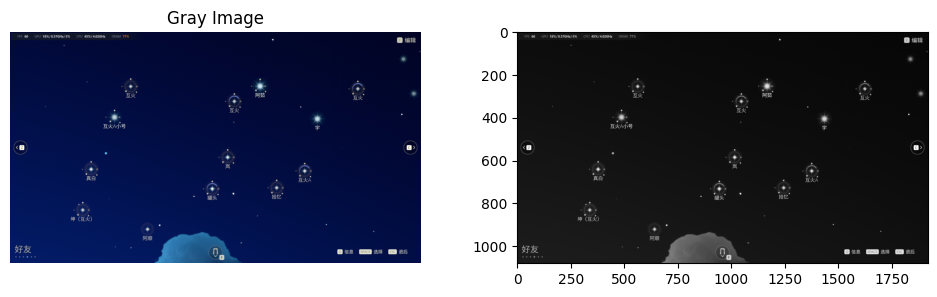

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12,3))

# 读取一下图片进行测试
image = cv2.imread(os.path.join("source", "data", "side.png"))
print("图像形状为:", image.shape)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

axes[0].imshow(image)
axes[0].axis('off')
axes[0].set_title("Origin Image")
axes[1].imshow(gray, cmap="gray")
axes[0].axis('off')
axes[0].set_title("Gray Image")
plt.show()

---
# __形状检测__
### __Hough 变换__
Hough变换是经典的检测直线的算法, 用来检测图像中的直线, 也可以用来检测图像中简单的结构

详情: https://zhuanlan.zhihu.com/p/203292567

### __LSD 算法__
一种号称有线性复杂度的直线检测算法

操作代码示例； 

创建LSD行段检测器对象
lsd = cv2.createLineSegmentDetector(0)

检测直线
lines, width, prec, nfa = lsd.detect(gaussian_blur_image)

在图像上绘制检测到的直线
drawn_img = lsd.drawSegments(image, lines)

### __腐蚀和膨胀__
腐蚀操作: 类似于卷积操作, 但是需要和掩膜进行比对, 如果都在掩膜内则保留, 如果不在则舍弃。

膨胀操作: 类似于加了 pad 的卷积, 童谣需要进行比对, 存在交叉区域则保留, 完全不存在就舍弃。

### __Harris 角点检测__
让一个窗口的中心位于灰度图像的一个位置 $(x,y)$，这个位置的像素灰度值为 $I(x,y)$

如果这个窗口分别向 $x$ 和 $y$ 方向移动一个小的位移 $u$ 和 $v$，到一个新的位置 $(x+u,y+v)$，这个位置的像素灰度值就是 $I(x+u,y+v)$

$I(x+u,y+v) - I(x,y)$ 就是窗口移动引起的灰度值的变化值

窗口在每个方向移动的像素灰度值变化量: $E(x,y) = \sum_{(x,y)} w(x,y) * (I(x+u,y+v) - I(x,y))^2 $

一阶泰勒展开: $I(x+u,y+v) \approx I(x,y) + uI'_x(x,y) + vI'_y(x,y)$

而梯度值 $I'_x(x,y) = \frac{\partial I(x,y)}{\partial x}, I'_y(x,y) = \frac{\partial I(x,y)}{\partial y}$ 可以通过 $Soebl$ 算子计算出

继续推导 $E(x,y) = \sum_{(x,y)} w(x,y) * (uI'_x(x,y) + vI'_y(x,y))^2 = \sum_{(x,y)} w(x,y) * (u^2I^{'2}_x + v^2I^{'2}_y + 2uvI'_xI'_y)^2 $

$E(x,y) = \sum_{(x,y)} w(x,y) * (uI'_x(x,y) + vI'_y(x,y))^2 = \begin{pmatrix} 
u & v
\end{pmatrix} M \begin{pmatrix} 
u \\
v
\end{pmatrix}$, 其中 $ M = \sum_{(x,y)} w(x,y) \begin{pmatrix} 
I^{'2}_x & I'_xI'_y\\
I'_xI'_y & I^{'2}_y
\end{pmatrix} = R^{-1} \begin{pmatrix} 
\lambda_1 & 0\\
0 & \lambda_2
\end{pmatrix} R$

因为这是黑塞矩阵所以一定可以对角化，这样我们就得到了 $E(x,y)$ 的一组基向量

我们使用角点响应函数 $\rho = \lambda_1\lambda_2 - \alpha(\lambda_1 + \lambda_2)^2 = det(M) - \alpha tr^2(M)$ 从而不需要做矩阵分解与对角化

设置一个阈值来检测角点或边缘即可, 还有改进版 Shi-Tomasi 角点检测方法

### __SIFT 特征提取__

太长太复杂，懒得敲了

生吃狠人专属链接：https://zhuanlan.zhihu.com/p/31844794941

OpenCV 还是贴心的做了代码

```python
# 创建分析器
sift = cv2.SIFT_create()
# 计算特征点
keypoints, descriptors = sift.detectAndCompute(gray, None)
# 绘制特征点
img = cv2.drawKeypoints(image, keypoints, outImage, color, flags)
```

还有 $SURF$ 算法，不过目前还在专利范围内


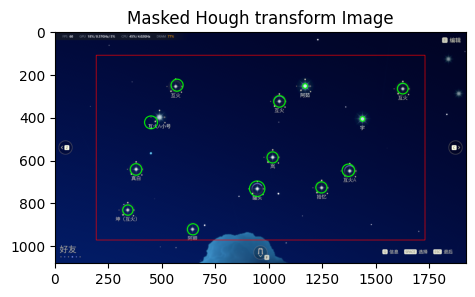

In [4]:
min_radius=1
max_radius=100

# 边界去除
height, width = gray.shape
border_ratio = 0.1
mask = np.zeros_like(gray, dtype=np.uint8)
border_x = int(width * border_ratio)
border_y = int(height * border_ratio)
inner_width = width - 2 * border_x
inner_height = height - 2 * border_y

cv2.rectangle(mask, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, -1)
masked_edges = cv2.bitwise_and(mask, gray, mask=mask)

# 使用霍夫圆变换检测圆形
circles = cv2.HoughCircles(
    masked_edges,               # 输入图像（边缘图）
    cv2.HOUGH_GRADIENT,         # 检测方法（梯度法）
    dp=1,                       # 累加器图像的分辨率与原图之比
    minDist=50,                 # 检测到的圆的圆心之间的最小距离
    param1=50,                  # Canny边缘检测器的高阈值
    param2=30,                  # 累加器阈值（越小检测到的圆越多）
    minRadius=min_radius,       # 最小圆半径
    maxRadius=max_radius        # 最大圆半径
)

# 复制原图用于绘制结果
result = image.copy()
cv2.rectangle(result, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, 2)

if circles is not None:
    circles = np.round(circles[0, :]).astype("int")
    for (x, y, r) in circles:
        cv2.circle(result, (x, y), r, (0, 255, 0), 4)
else:
    print("No detection.")


fig, axes = plt.subplots(1, 1, figsize=(10, 3))
axes.imshow(result, cmap="gray")
axes.set_title("Masked Hough transform Image")
plt.show()

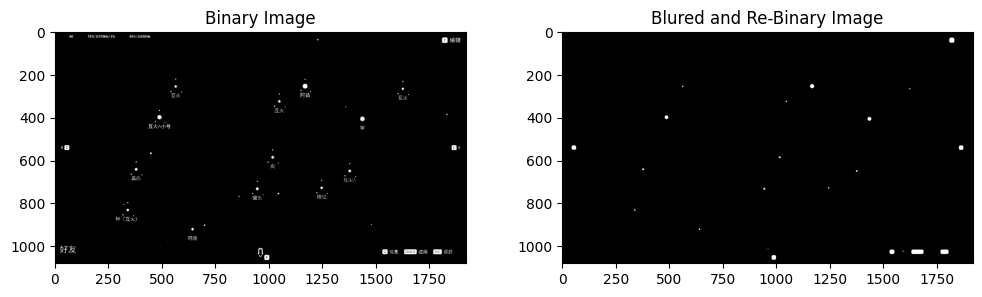

In [5]:
# 对灰度图进行二值化
_, binary_image = cv2.threshold(gray, 155, 255, cv2.THRESH_BINARY)
# 高斯平滑后再采样
blured_image = cv2.blur(binary_image, (9,9))
median_image = cv2.medianBlur(blured_image, 7)
# 重新二值化采样
_, rebinary_image = cv2.threshold(median_image, 155, 255, cv2.THRESH_BINARY)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].imshow(binary_image, cmap="gray")
axes[0].set_title("Binary Image")
axes[1].imshow(rebinary_image, cmap="gray")
axes[1].set_title("Blured and Re-Binary Image")
plt.show()

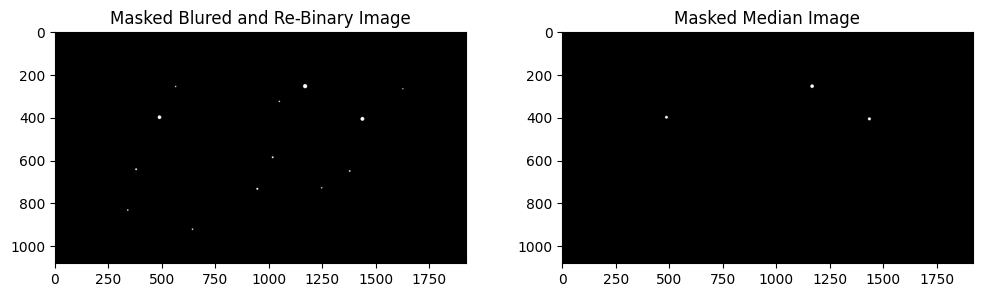

In [6]:
# 掩膜
height, width = gray.shape
border_ratio = 0.1
mask = np.zeros_like(gray, dtype=np.uint8)
border_x = int(width * border_ratio)
border_y = int(height * border_ratio)
inner_width = width - 2 * border_x
inner_height = height - 2 * border_y

cv2.rectangle(mask, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, -1)
masked_rebinary_image = cv2.bitwise_and(mask, rebinary_image, mask=mask)

masked_median_image = cv2.medianBlur(cv2.medianBlur(masked_rebinary_image, 11), 11)

fig, axes = plt.subplots(1, 2, figsize=(12,3))
axes[0].imshow(masked_rebinary_image, cmap="gray")
axes[0].set_title("Masked Blured and Re-Binary Image")
axes[1].imshow(masked_median_image, cmap="gray")
axes[1].set_title("Masked Median Image")
plt.show()

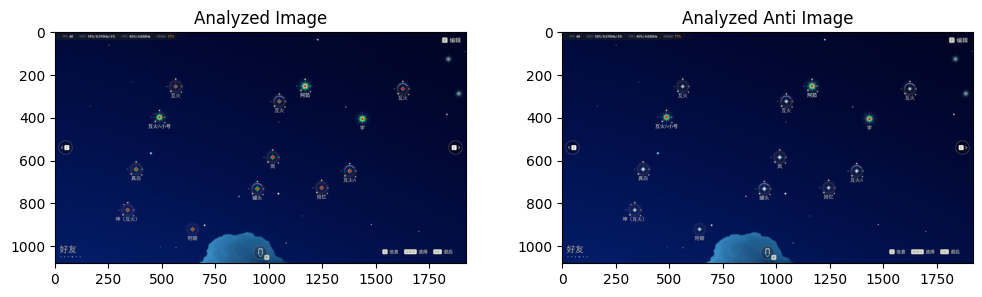

In [7]:
# 提取大范围亮色特征 (轮廓分析)
targets = []
origin_image = image.copy()
contours, _ = cv2.findContours(masked_rebinary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    center_x = x + w // 2
    center_y = y + h // 2
    targets.append((center_x, center_y))
    
    cv2.rectangle(origin_image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 绿色矩形
    cv2.circle(origin_image, (center_x, center_y), 5, (255, 0, 0), -1)  # 红色点

anti_image = image.copy()
acontours, _ = cv2.findContours(masked_median_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in acontours:
    x, y, w, h = cv2.boundingRect(contour)
    center_x = x + w // 2
    center_y = y + h // 2
    targets.append((center_x, center_y))
    
    cv2.rectangle(anti_image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 绿色矩形
    cv2.circle(anti_image, (center_x, center_y), 5, (255, 0, 0), -1)  # 红色点

fig, axes = plt.subplots(1, 2, figsize=(12,3))
axes[0].imshow(origin_image)
axes[0].set_title("Analyzed Image")
axes[1].imshow(anti_image)
axes[1].set_title("Analyzed Anti Image")
plt.show()

---
# __FFT 滤波与 Canny 算子__

高斯滤波器的算法是这样的 $ G(x,y) = e^{-\frac{x^2+y^2}{\sigma^2}} $，我们对它取减法就获得了高通滤波器

归一化算法 $ V_{new} = \frac{V_{old} - min(V_{olds})}{max(V_{olds}) - min(V_{olds})} \times 255 $

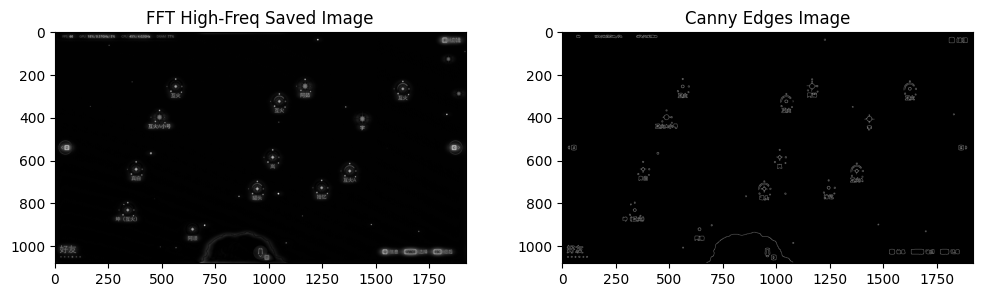

In [8]:
# 二维快速傅里叶变换, 抑制低频信号
f = np.fft.fft2(gray)
f_shift = np.fft.fftshift(f)

rows, cols = gray.shape
crow, ccol = rows//2, cols//2
sigma = 20
# 创建二维坐标网格，计算每个点到图像中心的偏移量
y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
mask_gaussian_high = 1 - np.exp(-(x*x + y*y)/(2*sigma**2))

# 与掩码相乘实现滤波
f_filtered_high = f_shift * mask_gaussian_high
# 逆中心化、FFT 逆变换、有理化
f_ishift_high = np.fft.ifftshift(f_filtered_high)
img_filtered_high = np.fft.ifft2(f_ishift_high)
img_filtered_high = np.abs(img_filtered_high)

# 像素值归一化后整数化
fft_image = np.uint8(cv2.normalize(img_filtered_high, None, 0, 255, cv2.NORM_MINMAX))

# Canny 算子
canny_threshold1=50
canny_threshold2=150

# 高斯模糊并边缘化
blurred = cv2.GaussianBlur(gray, (9, 9), 2)
edges = cv2.Canny(blurred, canny_threshold1, canny_threshold2)

fig, axes = plt.subplots(1, 2, figsize=(12,3))
axes[0].imshow(fft_image, cmap="gray")
axes[0].set_title("FFT High-Freq Saved Image")
axes[1].imshow(edges, cmap="gray")
axes[1].set_title("Canny Edges Image")
plt.show()

---
# __其他图像信息处理__

### __ddddocr 文字提取获取星盘状态__


OCR 识别结果: "好友", 坐标: [20, 23, 60, 61], [60, 22, 99, 61]


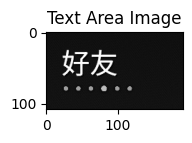

In [9]:
ocr = ddddocr.DdddOcr(show_ad=False)
text_detector = ddddocr.DdddOcr(det=True, show_ad=False)

# 边界去除
height, width = gray.shape
border_ratio = 0.1
mask = np.zeros_like(gray, dtype=np.uint8)
border_x = int(width * border_ratio)
border_y = int(height * border_ratio)

text_area = gray[height-border_y:, :border_x]

fig, axes = plt.subplots(1, 1, figsize=(3, 1))
axes.imshow(text_area, cmap='gray')
axes.set_title("Text Area Image")

_, encoded_img = cv2.imencode('.png', text_area)
img_bytes = encoded_img.tobytes()

result = ocr.classification(img_bytes)
det = text_detector.detection(img_bytes)

print("\nOCR 识别结果: \"{}\", 坐标: {}".format(result , ', '.join([str(det) for det in det])))

### __正则表达式匹配规则__

In [10]:
def re_keyword_detector(texts):
    """
    ASCII字符清洗检测子串, 子串是提前规定好的
    """
    patterns = [r'添[\x00-\x7F]{0,3}加[\x00-\x7F]{0,3}好[\x00-\x7F]{0,3}友', r'好[\x00-\x7F]{0,3}友', r'挚[\x00-\x7F]{0,3}友']
    dataframes = {
        '识别文本': [],
        '星盘页': [],
        '添加好友': [],
        '好友': [],
        '挚友': [],
    }

    for text in texts:
        matchs = list([bool(re.search(pattern, text)) for pattern in patterns])
        dataframes['星盘页'].append(True in matchs)
        dataframes['添加好友'].append(matchs[0] == True)
        dataframes['好友'].append(matchs[1] == True)
        dataframes['挚友'].append(matchs[2] == True)
        dataframes['识别文本'].append(text)
        
    return pd.DataFrame(dataframes)

texts = ['你~好~~~', '添加好友，同意一下', '好$*友', '']

pf = re_keyword_detector(texts)
pf

,识别文本,星盘页,添加好友,好友,挚友
0,你~好~~~,False,False,False,False
1,添加好友，同意一下,True,True,True,False
2,好$*友,True,False,True,False
3,,False,False,False,False


### __特殊点抑制__

In [11]:
def threhold_detector(gray, plot=False, show=False):
    '''
    利用检测点的圆形高亮特性确定目标点
    '''
    # 一顿操作最后只剩下需要的信息
    _, binary_image = cv2.threshold(gray, 155, 255, cv2.THRESH_BINARY)
    blured_image = cv2.blur(binary_image, (9,9))
    median_image = cv2.medianBlur(blured_image, 7)
    _, rebinary_image = cv2.threshold(median_image, 155, 255, cv2.THRESH_BINARY)
    
    # 掩膜
    height, width = gray.shape
    border_ratio = 0.1
    mask = np.zeros_like(gray, dtype=np.uint8)
    border_x = int(width * border_ratio)
    border_y = int(height * border_ratio)
    inner_width = width - 2 * border_x
    inner_height = height - 2 * border_y
    cv2.rectangle(mask, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, -1)
    masked_rebinary_image = cv2.bitwise_and(mask, rebinary_image, mask=mask)
    
    # 提取大范围亮色特征 (轮廓分析)
    targets, anti_targets = [], []
    origin_image = None
    if plot:
        origin_image = image.copy()
        # 绘制掩膜
        cv2.rectangle(origin_image, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, 2)

    # 抓住所有需要的点特征
    contours, _ = cv2.findContours(masked_rebinary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        center_x, center_y = x + w // 2, y + h // 2
        targets.append((center_x, center_y, w, h))
        
        if plot:
            cv2.rectangle(origin_image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 绿色矩形
            cv2.circle(origin_image, (center_x, center_y), 5, (255, 0, 0), -1)  # 红色点

    # 消除不需要的点特征
    masked_median_image = cv2.medianBlur(cv2.medianBlur(masked_rebinary_image, 11), 11)
    acontours, _ = cv2.findContours(masked_median_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in acontours:
        x, y, w, h = cv2.boundingRect(contour)
        center_x, center_y = x + w // 2, y + h // 2
        anti_targets.append((center_x, center_y, w, h))
        
        if plot:
            cv2.rectangle(origin_image, (x-5, y-5), (x+w+5, y+h+5), (255, 0, 0), 2)  # 红色矩形

    if show:
        fig, axes = plt.subplots(1, 1, figsize=(10, 6))
        axes.imshow(origin_image)
        axes.set_title("Analyzed Image")
        plt.show()
    
    return np.array(targets, dtype=np.float32), np.array(anti_targets, dtype=np.float32), origin_image

# 筛选出比较接近的几个点并且去掉就可以了
targets, anti_targets, plot_image = threhold_detector(gray, plot=False, show=False)
diff = np.expand_dims(targets[:,:2], axis=1) - np.expand_dims(anti_targets[:,:2], axis=0)
distance = np.sqrt(np.sum(diff*diff, axis=2))
point = np.where(distance < 15)[0]
from copy import copy
post = copy(targets[point])
pre = [i for i in targets.tolist() if i not in post]
print(pd.DataFrame(pre), "\n\n", pd.DataFrame(post), "\n\n", pd.DataFrame(targets))

        0      1     2     3
0   642.0  922.0   7.0   8.0
1   340.0  832.0   8.0   7.0
2   945.0  733.0  10.0  10.0
3  1245.0  728.0   7.0   7.0
4  1377.0  650.0   8.0   8.0
5   379.0  641.0  10.0   9.0
6  1017.0  585.0  10.0   9.0
7  1048.0  324.0   8.0   7.0
8  1625.0  265.0   6.0   5.0
9   563.0  254.0   7.0   7.0 

         0      1     2     3
0  1436.0  406.0  18.0  18.0
1   488.0  398.0  17.0  17.0
2  1168.0  253.0  19.0  20.0 

          0      1     2     3
0    642.0  922.0   7.0   8.0
1    340.0  832.0   8.0   7.0
2    945.0  733.0  10.0  10.0
3   1245.0  728.0   7.0   7.0
4   1377.0  650.0   8.0   8.0
5    379.0  641.0  10.0   9.0
6   1017.0  585.0  10.0   9.0
7   1436.0  406.0  18.0  18.0
8    488.0  398.0  17.0  17.0
9   1048.0  324.0   8.0   7.0
10  1625.0  265.0   6.0   5.0
11   563.0  254.0   7.0   7.0
12  1168.0  253.0  19.0  20.0


---
# __图像分类__

### __基础分类__

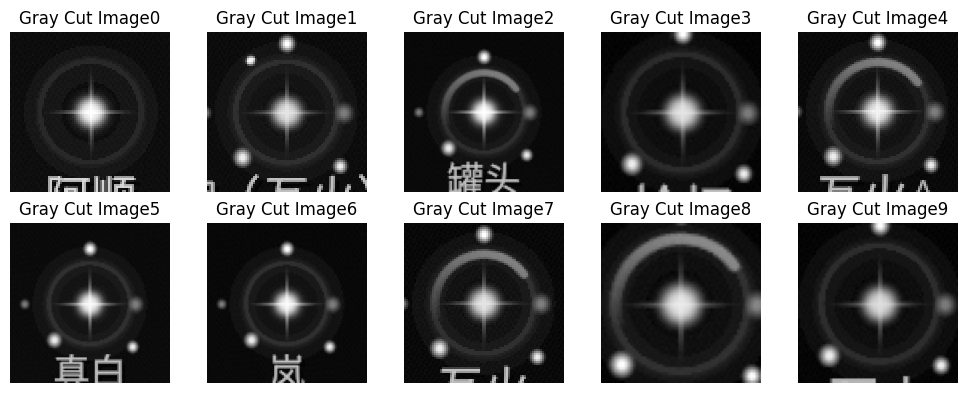

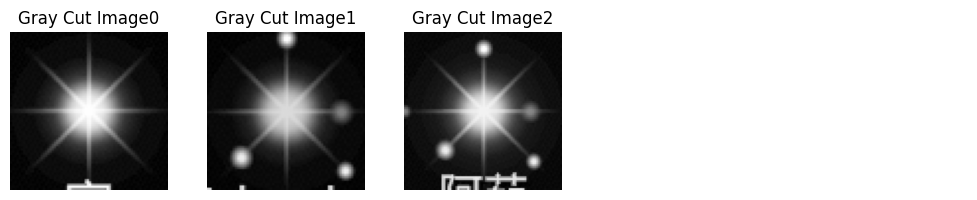

In [12]:
pre_scaler, post_scaler = 5, 2
pre_sub_gray = [gray[int(y-max(w,h)*pre_scaler):int(y+max(w, h)*pre_scaler), int(x-max(w, h)*pre_scaler):int(x+max(w, h)*pre_scaler)] for x, y, w, h in pre]
post_sub_gray = [gray[int(y-max(w,h)*post_scaler):int(y+max(w, h)*post_scaler), int(x-max(w, h)*post_scaler):int(x+max(w, h)*post_scaler)] for x, y, w, h in post]

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(pre_sub_gray):
        ax.imshow(pre_sub_gray[i], cmap='gray')
        ax.set_title('Gray Cut Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes.flatten()):
    if i < len(post_sub_gray):
        ax.imshow(post_sub_gray[i], cmap='gray')
        ax.set_title('Gray Cut Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

### __神经网络鉴别__

很神奇，不知道为什么神经网络的效果会这么差，所以不得已采用了一些方式去区分 __四角星__ 和 __八角星__, 目前已经废弃

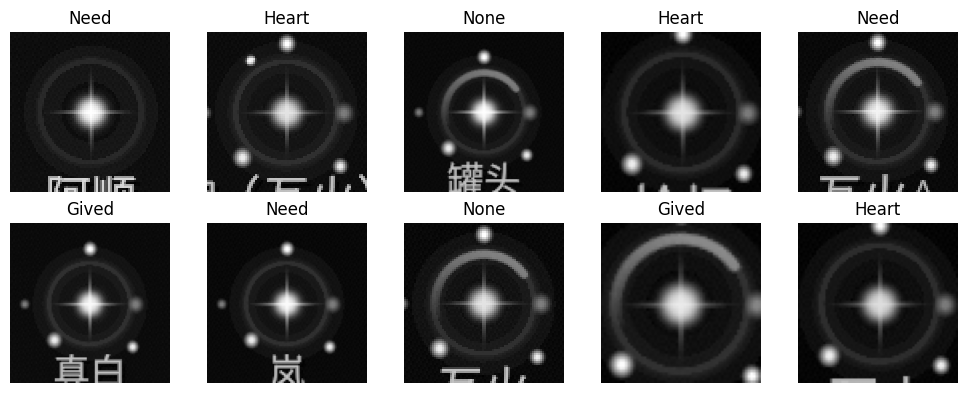

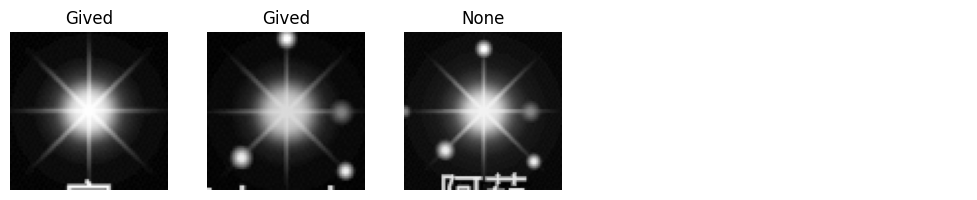

In [13]:
# 加载我们的 ResNet18 模型
model = resnet18()
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.fc = nn.Linear(in_features=512, out_features=4, bias=True)

MODEL_FOLDER = "models"
state_dict = {
    0: "None",
    1: "Need",
    2: "Gived",
    3: "Heart"
}

model.load_state_dict(torch.load(os.path.join(MODEL_FOLDER, "resnet18_model_best.pth"), weights_only=True))
model = model.to("cuda:0")

with torch.no_grad():
    pre_input = torch.tensor([cv2.resize(gray, (224, 224)) for gray in pre_sub_gray], dtype=torch.float32).unsqueeze(1).to("cuda:0")
    pred = torch.argmax(model(pre_input), dim=1).cpu().numpy()

    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flatten()):
        if i < len(pre_sub_gray):
            ax.imshow(pre_sub_gray[i], cmap='gray')
            ax.set_title('{}'.format(state_dict[pred[i]]))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    post_input = torch.tensor([cv2.resize(gray, (224, 224)) for gray in post_sub_gray], dtype=torch.float32).unsqueeze(1).to("cuda:0")
    pred = torch.argmax(model(post_input), dim=1).cpu().numpy()

    fig, axes = plt.subplots(1, 5, figsize=(10, 2))
    for i, ax in enumerate(axes.flatten()):
        if i < len(post_sub_gray):
            ax.imshow(post_sub_gray[i], cmap='gray')
            ax.set_title('{}'.format(state_dict[pred[i]]))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

### __区分四角星和八角星__

通过旋转 $45$ 度检测差异量即可得到中心的差值图像

四角星一定会出现八个相同的尖尖, 八角星会因为完全一致所以中间会什么都没有

旋转七次将所有的图像都进行分析，可以有效的抑制文字的影响，只剩下中间的不变量和极特殊的外围对称亮点

光遇的前端设计导致两边对称的概率不大，所以这个的概率也低的吓人

同时就算有一般也不会超过三组，而且长度远小于中心的对称部分，所以我们可以用这个作为特征

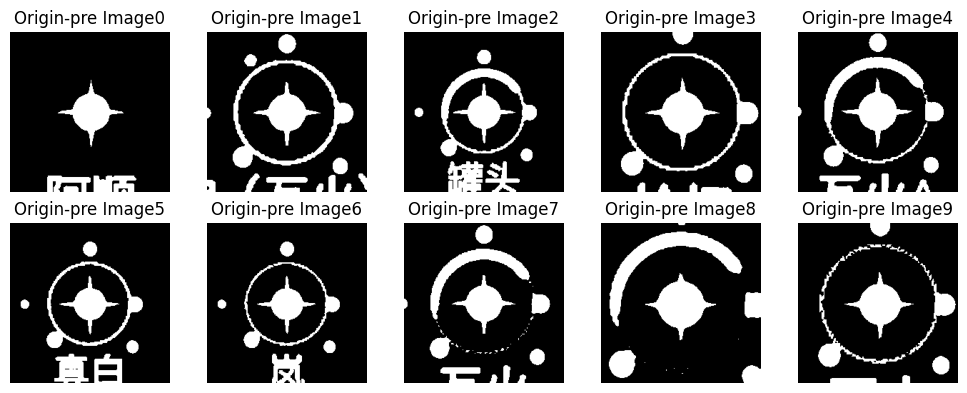

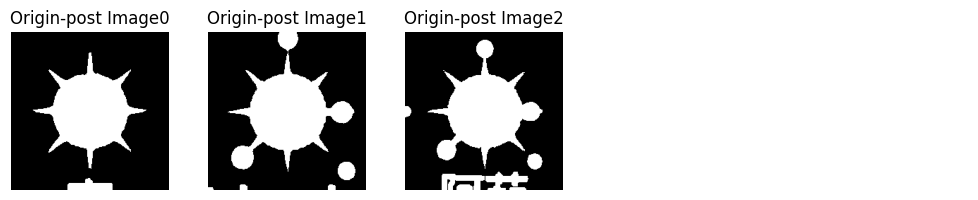

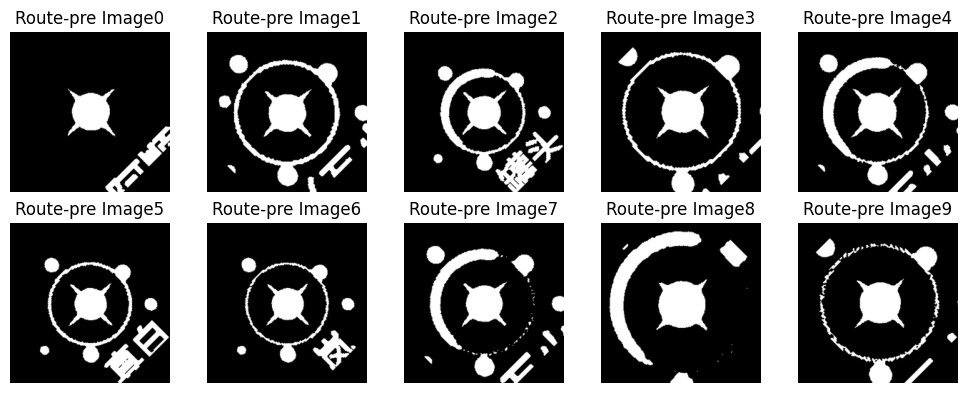

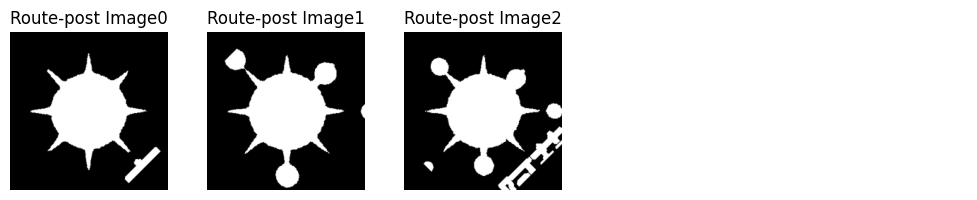

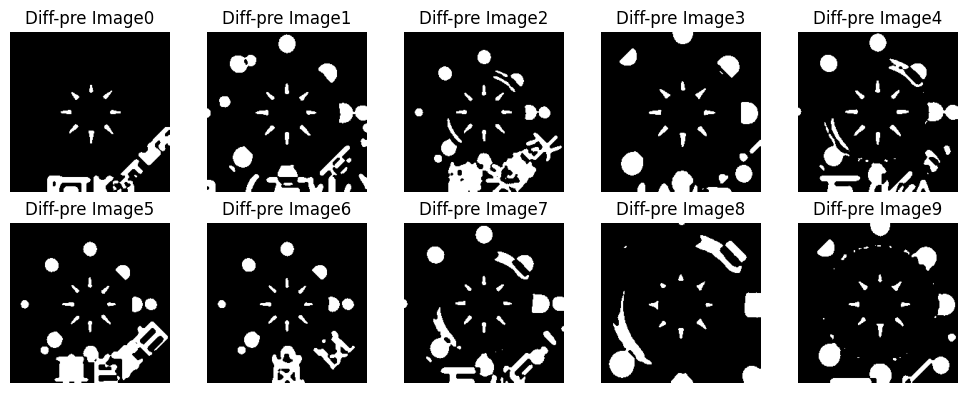

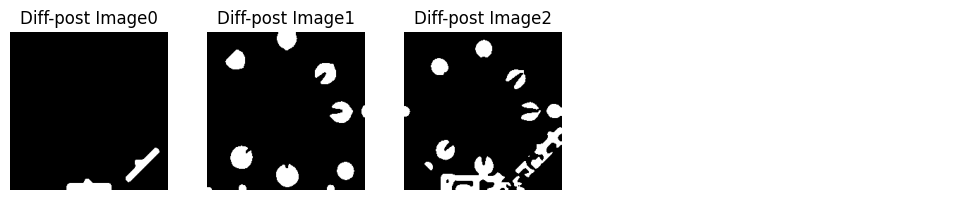

In [14]:
# 旋转45度计算差值
rotation_matrix = cv2.getRotationMatrix2D((112,112), 45, 1.0)

resize_pre = [cv2.threshold(cv2.resize(gray, (224, 224)), 50, 255, cv2.THRESH_BINARY)[1] for gray in pre_sub_gray]
route_resize_pre = [cv2.warpAffine(gray, rotation_matrix, (224,224)) for gray in resize_pre]
diff_pre = [np.abs(np.array(r1, dtype=np.float32) - np.array(r2, dtype=np.float32)) for r1, r2 in zip(route_resize_pre, resize_pre)]
diff_pre = [cv2.threshold(cv2.blur(gray, (5,5)), 150, 255, cv2.THRESH_BINARY)[1] for gray in diff_pre]

resize_post = [cv2.threshold(cv2.resize(gray, (224, 224)), 50, 255, cv2.THRESH_BINARY)[1] for gray in post_sub_gray]
route_resize_post = [cv2.warpAffine(gray, rotation_matrix, (224,224)) for gray in resize_post]
diff_post = [np.abs(np.array(r1, dtype=np.float32) - np.array(r2, dtype=np.float32)) for r1, r2 in zip(route_resize_post, resize_post)]
diff_post = [cv2.threshold(cv2.blur(gray, (5,5)), 150, 255, cv2.THRESH_BINARY)[1] for gray in diff_post]

# 原图像
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(resize_pre):
        ax.imshow(resize_pre[i], cmap='gray')
        ax.set_title('Origin-pre Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes.flatten()):
    if i < len(resize_post):
        ax.imshow(resize_post[i], cmap='gray')
        ax.set_title('Origin-post Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

# 旋转图像
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(route_resize_pre):
        ax.imshow(route_resize_pre[i], cmap='gray')
        ax.set_title('Route-pre Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes.flatten()):
    if i < len(route_resize_post):
        ax.imshow(route_resize_post[i], cmap='gray')
        ax.set_title('Route-post Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(diff_pre):
        ax.imshow(diff_pre[i], cmap='gray')
        ax.set_title('Diff-pre Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes.flatten()):
    if i < len(diff_post):
        ax.imshow(diff_post[i], cmap='gray')
        ax.set_title('Diff-post Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

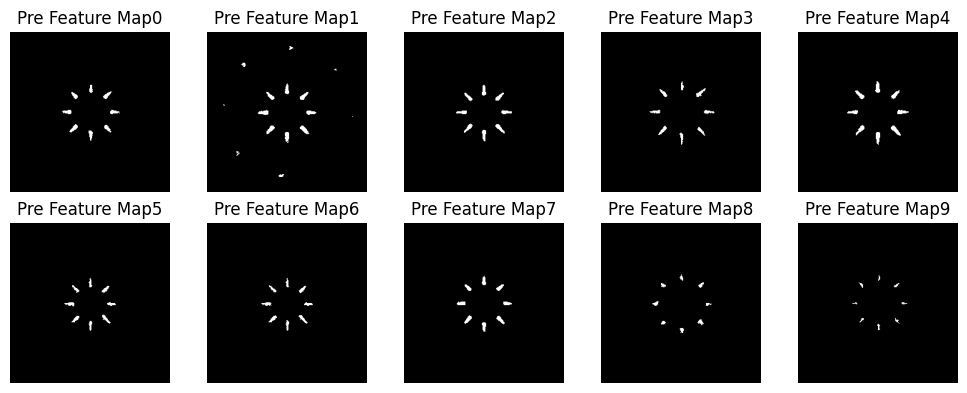

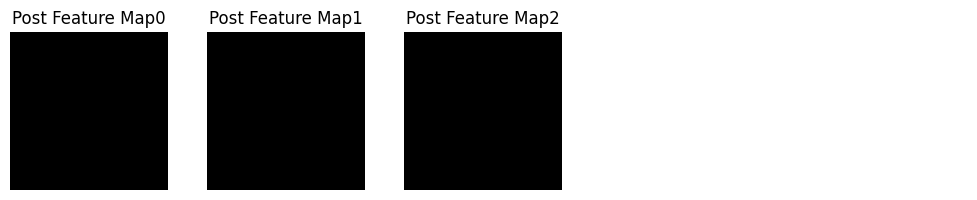

In [15]:
# 使图像旋转八次并且堆叠在一起
feature_map = [diff_pre]
for i in range(7):
    feature_map.append([cv2.warpAffine(gray, rotation_matrix, (224,224)) for gray in feature_map[-1]])
stacked_features = np.array(feature_map)
pre_result = np.ones((len(diff_pre), 224, 224), dtype=np.uint8)
for i in range(8):
    pre_result = pre_result * (stacked_features[i] > 0)
pre_result = pre_result.astype(np.uint8)

feature_map = [diff_post]
for i in range(7):
    feature_map.append([cv2.warpAffine(gray, rotation_matrix, (224,224)) for gray in feature_map[-1]])
stacked_features = np.array(feature_map)
post_result = np.ones((len(diff_post), 224, 224), dtype=np.uint8)
for i in range(8):
    post_result = post_result * (stacked_features[i] > 0)
post_result = post_result.astype(np.uint8)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(pre_result):
        ax.imshow(pre_result[i], cmap='gray')
        ax.set_title('Pre Feature Map{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes.flatten()):
    if i < len(post_result):
        ax.imshow(post_result[i], cmap='gray')
        ax.set_title('Post Feature Map{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

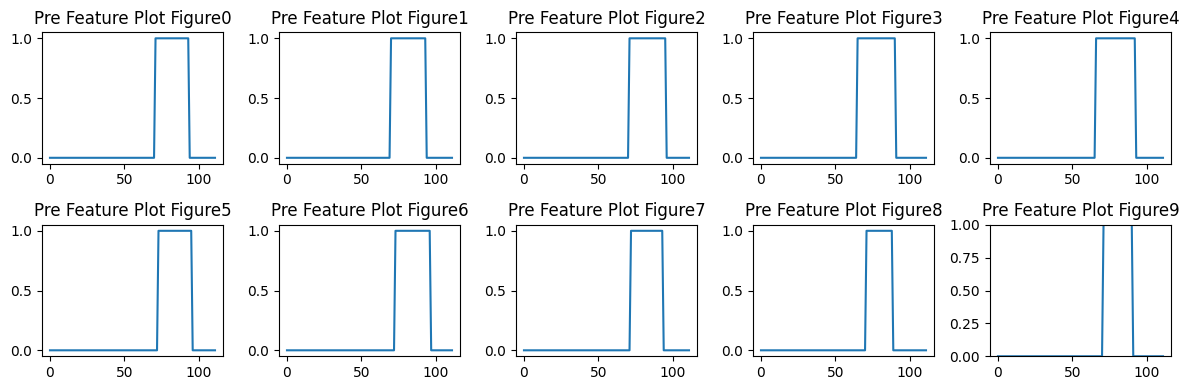

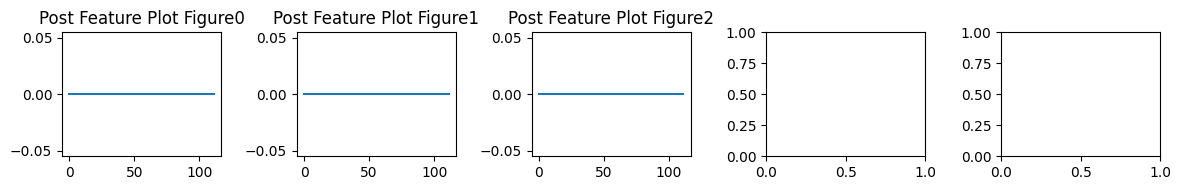

In [16]:
# 绘制四分方向的折线图, 因为我们已经确定是 (224,224)的图像了
pre_analyze_list, post_analyze_list = [], []

pre_feature_list = []
for gray in pre_result:
    x = np.arange(224)
    y = np.arange(224)
    xx, yy = np.meshgrid(x, y)
    
    lines = [gray[112, :], gray[:, 112], gray[yy == xx], gray[yy == 223 - xx]]
    pre_feature_list.append(np.array(lines))

fig, axes = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(pre_feature_list):
        # 存在就记录, 和前面的不同
        data = np.average(np.array([(pre_feature_list[i][j] + pre_feature_list[i][j][::-1])/2 for j in range(pre_feature_list[i].shape[0])]), axis=0)
        binary_data = np.where(data != 0, 1, 0)
        first_half = binary_data[:112]
        second_half = binary_data[112:][::-1]
        comparison = np.logical_and(first_half, second_half)
        processed = median_filter(comparison, size=11)
        pre_analyze_list.append([1 if i else 0 for i in processed])
        
        ax.plot(processed)
        ax.set_title('Pre Feature Plot Figure{}'.format(i))
        plt.ylim(0, 1)
plt.tight_layout()
plt.show()

post_feature_list = []
for gray in post_result:
    x = np.arange(224)
    y = np.arange(224)
    xx, yy = np.meshgrid(x, y)
    
    lines = [gray[112, :], gray[:, 112], gray[yy == xx], gray[yy == 223 - xx]]
    post_feature_list.append(np.array(lines))

fig, axes = plt.subplots(1, 5, figsize=(12, 2))
for i, ax in enumerate(axes.flatten()):
    if i < len(post_feature_list):
        data = np.average(np.array([(post_feature_list[i][j] + post_feature_list[i][j][::-1])/2 for j in range(post_feature_list[i].shape[0])]), axis=0)
        binary_data = np.where(data != 0, 1, 0)
        first_half = binary_data[:112]
        second_half = binary_data[112:][::-1]
        comparison = np.logical_and(first_half, second_half)
        processed = median_filter(comparison, size=11)
        post_analyze_list.append([1 if i else 0 for i in processed])
        
        ax.plot(processed)
        ax.set_title('Post Feature Plot Figure{}'.format(i))
        plt.ylim(0, 1)
plt.tight_layout()
plt.show()

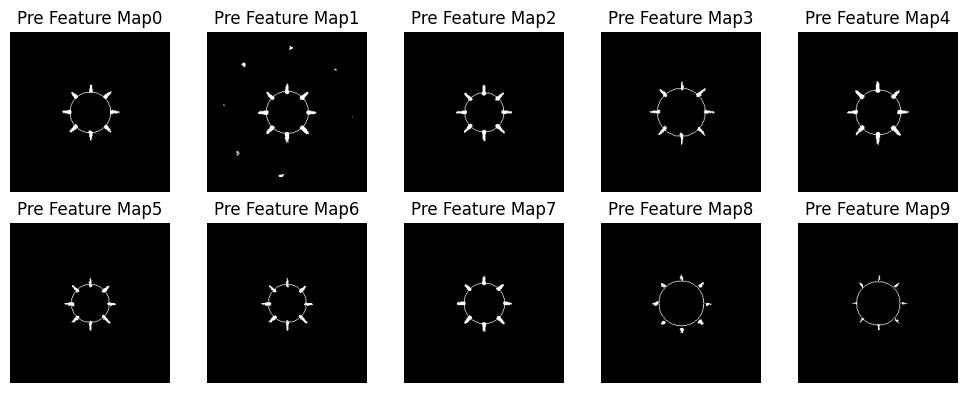

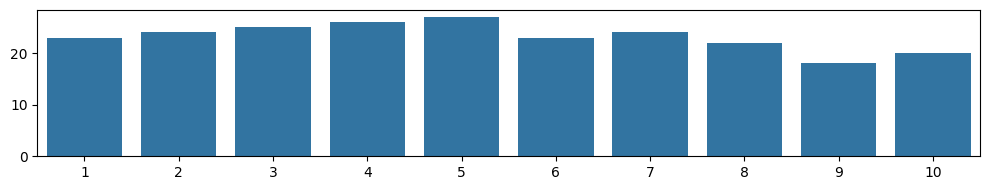

In [17]:
pre_radius_list = []
for data in pre_analyze_list:
    diff = np.diff(data[50:]) # 我们假设圆环不可能出现在外边界, 因为我毕竟抓了好几倍边长呢
    rising_edges = np.where(diff == 1)[0] + 51
    falling_edges = np.where(diff == -1)[0] + 51

    if len(rising_edges) != len(falling_edges):
        raise RuntimeError("上升沿与下降沿不匹配")
        
    if len(rising_edges) == 0:
        pre_radius_list.append([False, -1, -1])
    else:
        index = np.argmax(falling_edges - rising_edges)
        radius = 112 - (falling_edges[index] + rising_edges[index])/2
        pre_radius_list.append([True, radius, falling_edges[index] - rising_edges[index]])

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flatten()):
    if i < len(pre_result):
        pre_origin_result = pre_result[i].copy()
        cv2.circle(pre_origin_result, (112,112), int(pre_radius_list[i][1]), 1, 1)
        ax.imshow(pre_origin_result, cmap='gray')
        ax.set_title('Pre Feature Map{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 1, figsize=(10, 2))
sns.barplot(x=np.arange(1,len(pre_radius_list)+1), y=[i[2] for i in pre_radius_list])
ax.set_title("Analyze Figure")
plt.tight_layout()
plt.show()

看起来这一部分的半径都应该至少大于 12, 那我们解析这个最长的这一部分有没有在半径 70、中心为圆心的圆内，且采样点有明确的八角星特性

---
# __特征检测__

### __星屑检测__
区分好四角星和八角星之后我们可以检测其周围是否有星屑，我们还是通过将中心掩盖的方式来计算我们的其余部分

这时候文字成了最大的障碍，可以我们可以通过矩形切分的方式，只要有两个 $box$ 中没有复杂纹理且有圆形出现，那么我们就认为有星屑

而在光遇中，我们只需要检测 $cls-2$ 的星屑就可以了，$cls-1$ 是一定会点击的所以我们可以用星盘状态来暴力处理

如果出现全零选区，那么这个就一定是没有需要收的心火，那么我们就舍弃他

第 1 组的标签为: 1
第 2 组的标签为: 0
第 3 组的标签为: 0


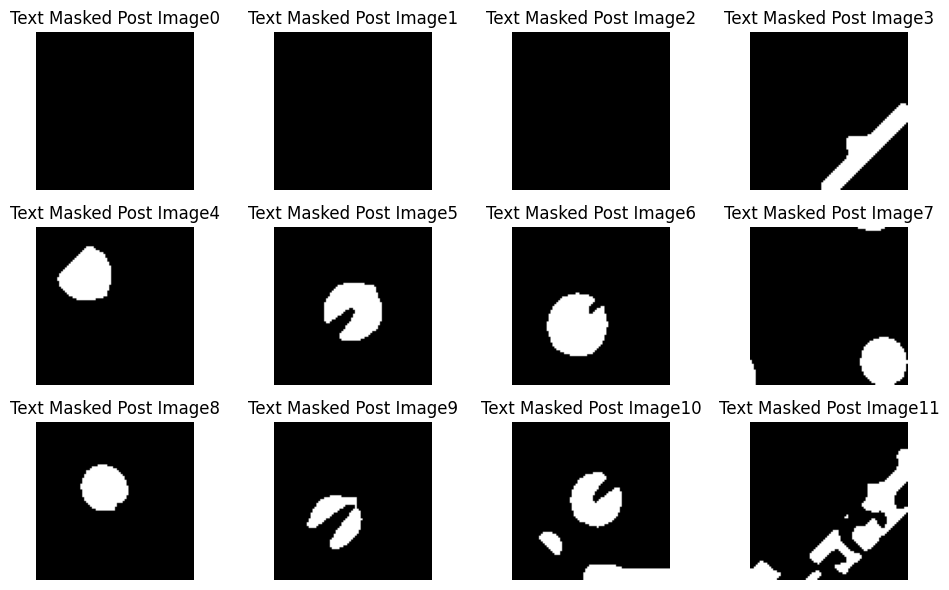

In [18]:
# 建立四个矩形选区, 如果有部分没有白色区域那么我们就认为它不是我们要找的
bound = 15
split_post = [[img_post[bound:112-bound, bound:112-bound], img_post[bound:112-bound, 112+bound:224-bound], img_post[112+bound:224-bound, bound:112-bound], img_post[112+bound:224-bound, 112+bound:224-bound]] for img_post in diff_post]

labels = []
for group in split_post:
    all_zero = False
    for img in group:
        if np.all(img == 0):  
            all_zero = True
            break
    labels.append(1 if all_zero else 0)  

for i, label in enumerate(labels):
    print(f"第 {i + 1} 组的标签为: {label}")

fig, axes = plt.subplots(len(split_post), 4, figsize=(10, 2*len(split_post)))
for i, ax in enumerate(axes.flatten()):
    if i < len(split_post)*4:
        ax.imshow(split_post[i//4][i%4], cmap='gray')
        ax.set_title('Text Masked Post Image{}'.format(i))
    ax.axis('off')
plt.tight_layout()
plt.show()

### __红色爱心检测__
我们准备使用色相检测的方式检测图像中是否存在红色区块，我们直接用 $HSV$ 图像进行色相处理即可

颜色不能卡太死，而且基本上每个送心的人也都会送心火，所以我们要排除掉这些小点才可以

不过我们可以通过简单的算法来定位大点，之后根据大点范围来确定心的位置，只是我们不需要检测中心圆形特征了

直接拿出来就可以用并且进去之后收完心还要再出来不然可能会有问题，所以第一次直接执行爱心检测才行，之后慢慢送心火

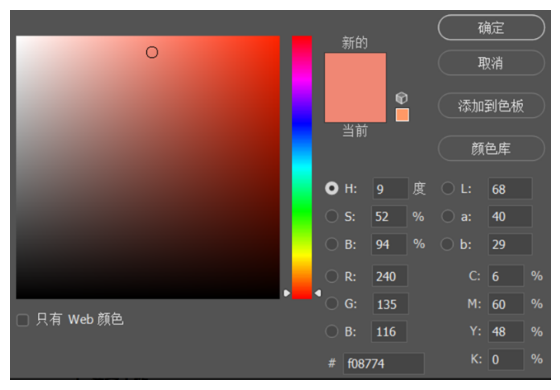

,H,S,V
#f08774,5,132,240


In [19]:
fig, ax = plt.subplots(1,1,figsize=(15,4))
ax.imshow(cv2.cvtColor(cv2.imread(os.path.join("source","hearts.png")), cv2.COLOR_BGR2RGB))
ax.axis("off")
plt.tight_layout()
plt.show()

r, g, b = 240, 135, 116
rgb_color = np.uint8([[[r, g, b]]]) # (1,1,3) 单像素 RGB 图片
hsv_color = cv2.cvtColor(rgb_color, cv2.COLOR_RGB2HSV)
pf = pd.DataFrame([hsv_color[0][0].tolist()], columns=['H','S','V'], index=['#f08774'])
pf

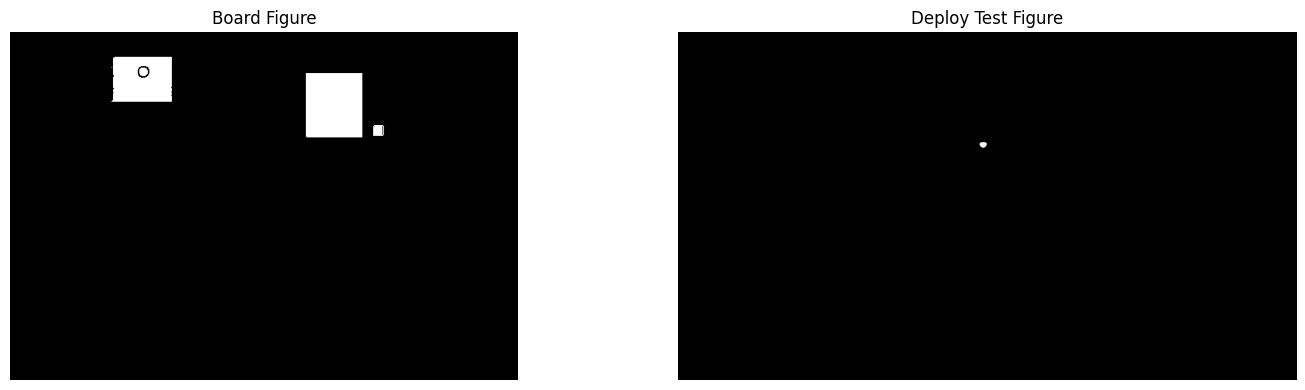

In [20]:
def hue_detector(hsv_image, hue_threhold=15):
    hue_ranges = []
    
    # 计算色相环, 其他阈值卡死为 30
    if hue_threhold > 5:
        hue_ranges.append([185-hue_threhold, 179])
        hue_ranges.append([0, hue_threhold+4])
    else:
        hue_ranges.append([5-hue_threhold, hue_threhold+4])
    
    height, width = hsv_image.shape[:2]
    mask = np.zeros((height, width), dtype=np.uint8)
    if hue_threhold > 5:
        hue_masks = [cv2.inRange(hsv_image, np.array([lower_hue, 100, 210]), np.array([upper_hue, 160, 270]))for (lower_hue, upper_hue) in hue_ranges]
        for hue_mask in hue_masks:
            mask = cv2.bitwise_or(mask, hue_mask)
    return mask

test_image = cv2.cvtColor(cv2.imread(os.path.join("source","hearts.png")), cv2.COLOR_BGR2RGB)
deploy_image = cv2.cvtColor(cv2.imread(os.path.join("source","data","main2.png")), cv2.COLOR_BGR2RGB)
hsv_test_image = cv2.cvtColor(test_image, cv2.COLOR_RGB2HSV)
hsv_deploy_image = cv2.cvtColor(deploy_image, cv2.COLOR_RGB2HSV)

mask1 = hue_detector(hsv_test_image)*255
mask2 = hue_detector(hsv_deploy_image)*255
# 把小星屑当成椒盐噪声就可以了, 安排两次中值滤波
median_mask = cv2.medianBlur(cv2.medianBlur(mask2, 11), 7)

fig, ax = plt.subplots(1,2,figsize=(15,4))
ax[0].imshow(mask1, cmap="gray")
ax[0].axis("off")
ax[0].set_title("Board Figure")
ax[1].imshow(median_mask, cmap="gray")
ax[1].axis("off")
ax[1].set_title("Deploy Test Figure")
plt.tight_layout()
plt.show()

### __收取爱心__
不需要检测信封，因为我们可以直接用 ↑ 把光标移动到最上面，之后我们按两次 ↓ 就可以了

就这么简单，别的不需要，但是考虑到不能错误删除好友，所以我们还是只能按一下 Space

如果 Esc 之后星盘没有变化，就认为这个没有取成功，我们直接放弃就可以，这个算特殊情况

---
# __数据定位__

### __文字 $\rightarrow$ 星星定位__
我们需要使用 OCR 技术边识别文字边定位信息, 同时还要去掉复杂的一对一关系

一般的我们先根据它有一个大致的判断之后我们进星盘内查看第一个选框的昵称就可以了 (OCR方案已废弃)

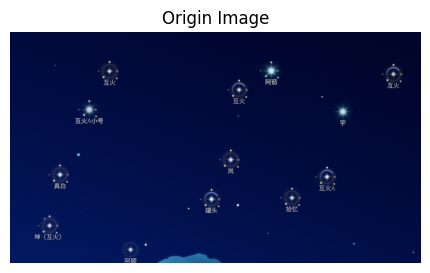

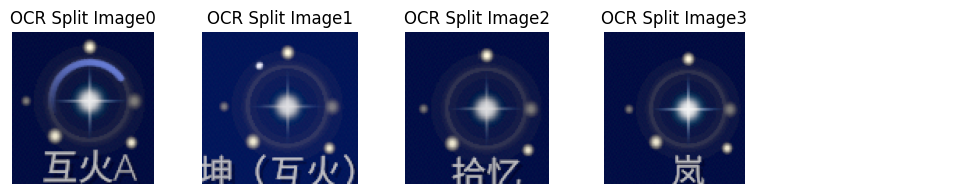

,x1,y1,x2,y2
0,1135,497,1226,595
1,93,676,193,774
2,1001,570,1094,669
3,767,424,864,529


In [21]:
auto_ocr = ddddocr.DdddOcr(det=True, show_ad=False)

image = cv2.imread(os.path.join("source", "data", "side.png"))
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

height, width = gray.shape
border_ratio = 0.1
mask = np.zeros_like(gray, dtype=np.uint8)
border_x = int(width * border_ratio)
border_y = int(height * border_ratio)
inner_width = width - 2 * border_x
inner_height = height - 2 * border_y

image = image[border_y:border_y+inner_height, border_x:border_x+inner_width]
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

_, encoded_img = cv2.imencode('.png', image)
img_bytes = encoded_img.tobytes()
ocr_detection_result = auto_ocr.detection(img_bytes)

fig, ax = plt.subplots(1, 1, figsize=(12,3))
ax.imshow(image)
ax.axis('off')
ax.set_title("Origin Image")
plt.show()

if len(ocr_detection_result) != 0:
    fig, axes = plt.subplots((len(ocr_detection_result)-1)//5+1, 5, figsize=(10, 2*((len(ocr_detection_result)-1)//5+1)))
    for i, ax in enumerate(axes.flatten()):
        if i < len(ocr_detection_result):
            ocr_split_image = image[ocr_detection_result[i][1]:ocr_detection_result[i][3], ocr_detection_result[i][0]:ocr_detection_result[i][2]]
            ax.imshow(ocr_split_image)
            ax.set_title('OCR Split Image{}'.format(i))
        ax.axis('off')
    plt.tight_layout()
    plt.show()

pd.DataFrame(ocr_detection_result, columns=["x1","y1","x2","y2"])

### __SIFT 特征区域匹配__
不同尺度下的特征匹配，但是目前使用的图片是直接截图获得的，所以直接用模板匹配也可以

测试了一下发现效果不好，所以这个方案也打算放弃了(已废弃)

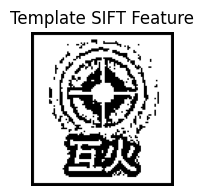

模板图特征点数量: 53
目标图特征点数量: 1853
筛选后匹配点数量: 26


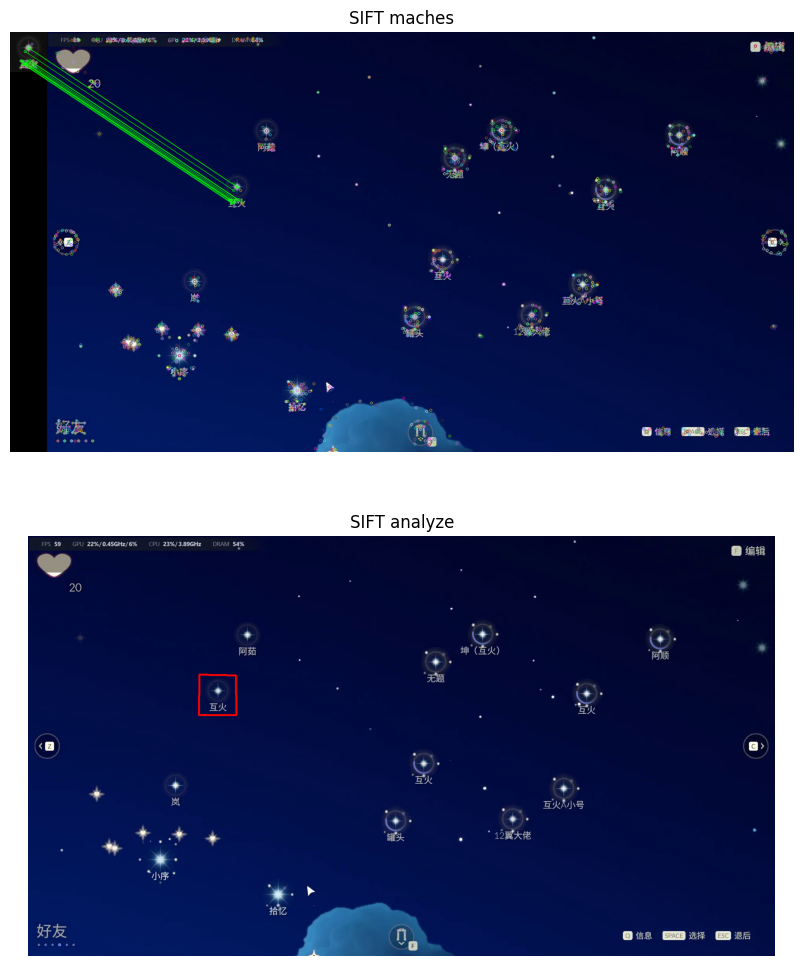

In [25]:
# 白底黑字模板图
template = cv2.imread(os.path.join("source", 'template.jpg'))
template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
# 使用自适应阈值二值化
template_bin = cv2.adaptiveThreshold(
    template, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY, 11, 2
)
# _, template_bin = cv2.threshold(template, 127, 255, cv2.THRESH_BINARY_INV)

# 待匹配目标图
target = cv2.imread(os.path.join("source", 'target.jpg'))
target_gray = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
target_color = target.copy()

sift = cv2.SIFT_create(
    nfeatures=0,               # 默认0无限制，可能导致计算慢
    contrastThreshold=0.04,   # 降低对比度阈值，提取更多弱特征（默认0.04）
    edgeThreshold=10,          # 降低边缘阈值，允许靠近边缘的特征点（默认10）
    sigma=1.6                  # 高斯模糊系数，控制尺度空间初始层（默认1.6）
)
mask = np.zeros_like(template)

# 模板图：提取特征点和描述子
contours, _ = cv2.findContours(template_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    cv2.drawContours(mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    
    # 可视化轮廓检测结果
    contour_vis = template_bin.copy()
    cv2.drawContours(contour_vis, [largest_contour], -1, (0, 255, 0), 2)
    plt.figure(figsize=(5,2))
    plt.imshow(contour_vis, cmap='gray')
    plt.title('Template SIFT Feature')
    plt.axis('off')
    plt.show()

kp_template, des_template = sift.detectAndCompute(template, mask)
kp_target, des_target = sift.detectAndCompute(target_gray, None)
print(f"模板图特征点数量: {len(kp_template)}")
print(f"目标图特征点数量: {len(kp_target)}")

# 特征匹配与筛选
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=8)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des_template, des_target, k=2)

# 放宽比率测试阈值
good_matches = []
for m, n in matches:
    if m.distance < 0.7 * n.distance:  # 调整阈值到 0.6
        good_matches.append(m)

print(f"筛选后匹配点数量: {len(good_matches)}")

# 几何验证（单应性矩阵 + RANSAC）
if len(good_matches) > 10:  # 降低匹配点数量要求
    src_pts = np.float32([kp_template[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_target[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
    
    if M is not None:
        matches_mask = mask.ravel().tolist()
        
        h, w = template.shape
        template_corners = np.float32([[0, 0], [0, h], [w, h], [w, 0]]).reshape(-1, 1, 2)
        target_corners = cv2.perspectiveTransform(template_corners, M)
        
        # 绘制匹配结果
        draw_params = dict(
            matchColor=(0, 255, 0),
            singlePointColor=None,
            matchesMask=matches_mask,
            flags=cv2.DrawMatchesFlags_DEFAULT
        )
        match_img = cv2.drawMatches(template, kp_template, target, kp_target, good_matches, None, **draw_params)
        
        cv2.polylines(target_color, [np.int32(target_corners)], isClosed=True, color=(0, 0, 255), thickness=4)
        
        plt.figure(figsize=(12, 12))
        plt.subplot(211), plt.imshow(match_img[:, :, ::-1]), plt.title('SIFT maches'), plt.axis('off')
        plt.subplot(212), plt.imshow(target_color[:, :, ::-1]), plt.title('SIFT analyze'), plt.axis('off')
        plt.show()
    else:
        print("警告：无法计算单应性矩阵，可能是匹配点质量不佳")
else:
    print("警告：匹配点不足，未检测到文字区域")
    if len(good_matches) > 0:
        match_img = cv2.drawMatches(template, kp_template, target, kp_target, good_matches, None)
        plt.figure(figsize=(15,6))
        plt.imshow(match_img[:, :, ::-1])
        plt.title(f'SIFT pre-maches ({len(good_matches)})')
        plt.axis('off')
        plt.show()

### __分块特征提取__
我们将整个图片分割成一些小块，加上步长实现对每个小块进行检测

假设我们的图片是 1920x1080 的，那么我们就可以令卷积核是 $(192,108)$，步长为 $(96,54)$

根据卷积计算公式 $F_{out} = \frac{F_{in} - K + 2P}{S} + 1 = 19$

已知这是一个 $19*19$ 的特征图集

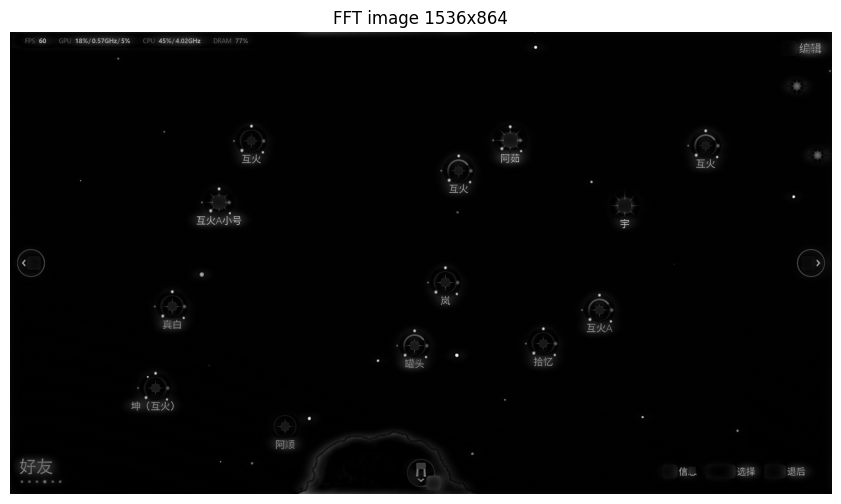

height: 864, width: 1536



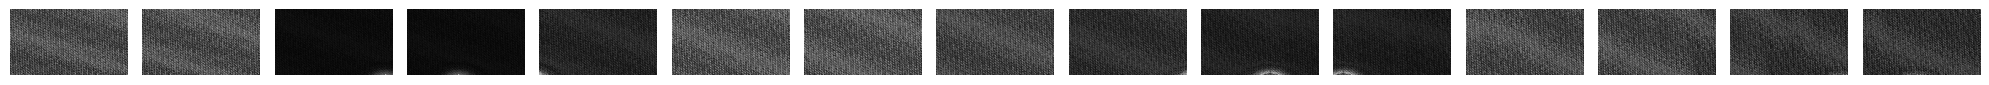

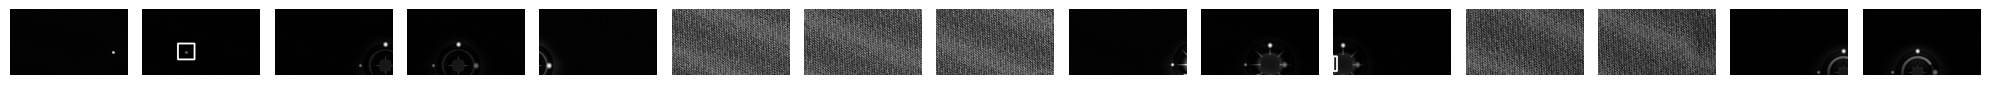

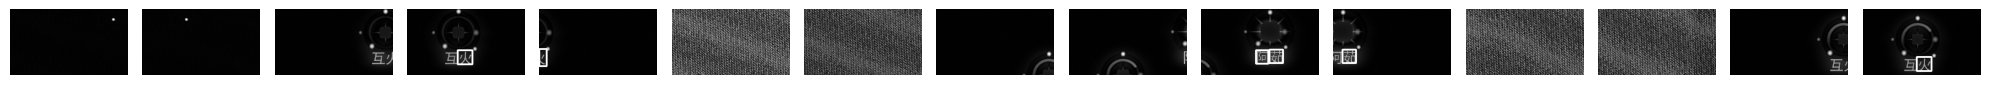

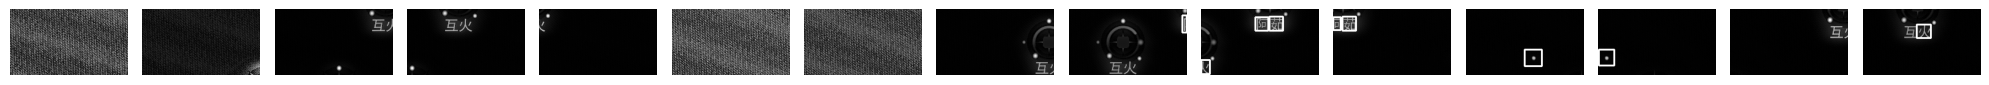

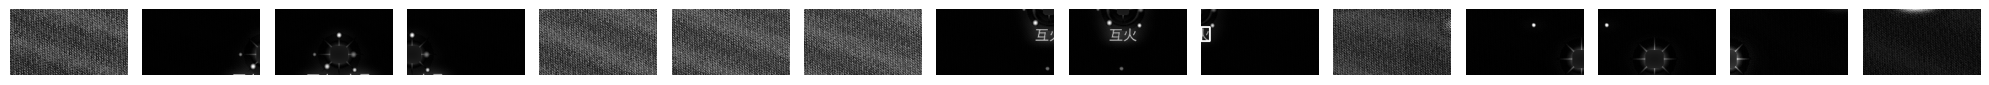

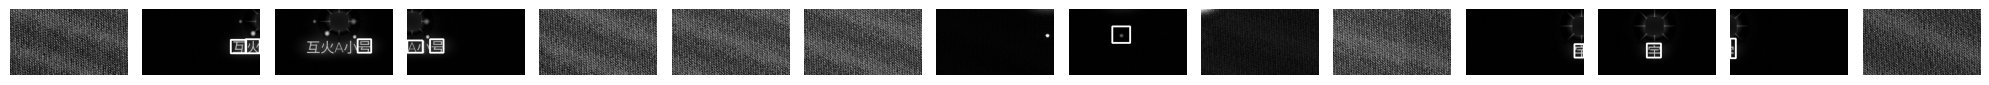

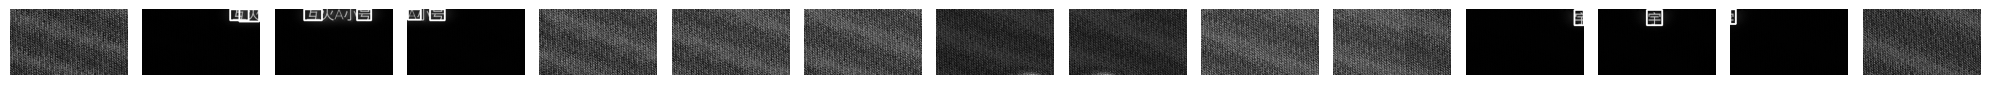

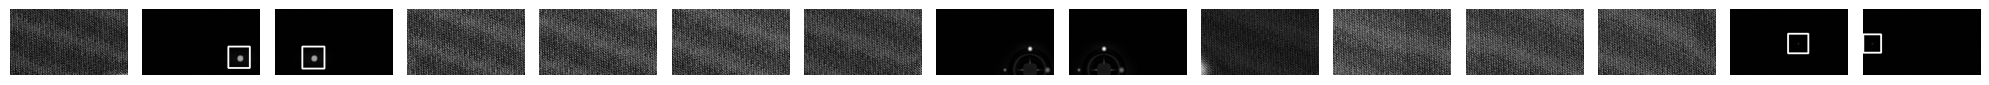

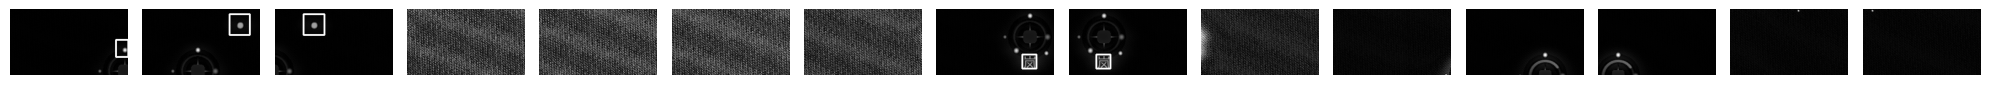

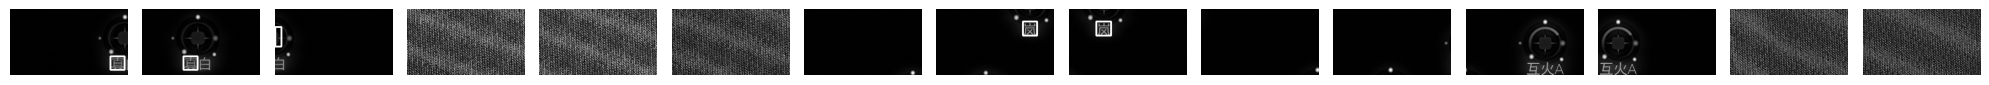

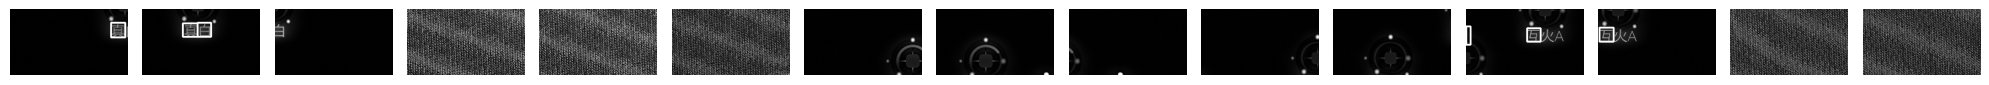

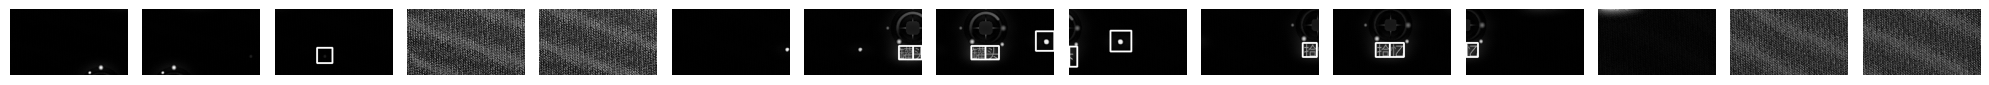

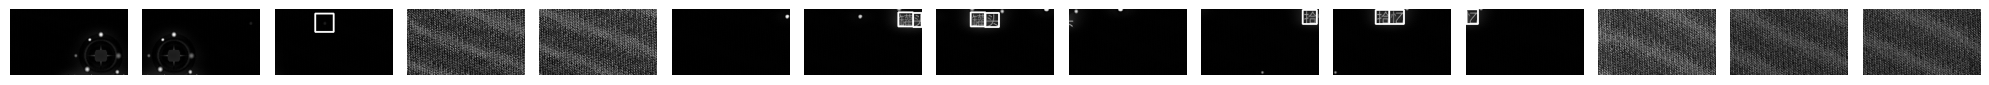

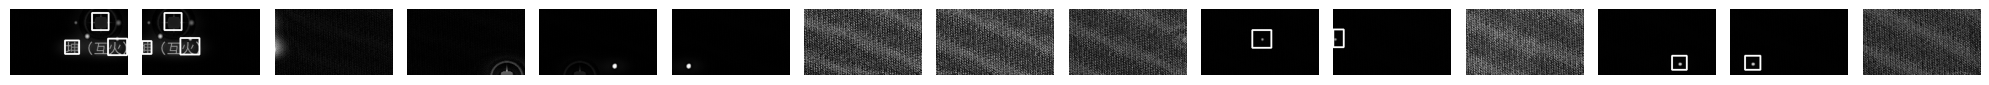

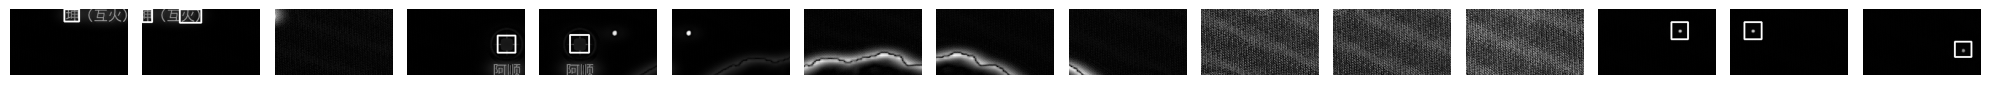

Done.


In [33]:
image = cv2.imread(os.path.join("source", "data", "side.png"))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

_, binary_image = cv2.threshold(gray, 155, 255, cv2.THRESH_BINARY)
blured_image = cv2.blur(binary_image, (9,9))
median_image = cv2.medianBlur(blured_image, 7)
_, rebinary_image = cv2.threshold(median_image, 155, 255, cv2.THRESH_BINARY)
blured_image = cv2.blur(rebinary_image, (13,13))
_, rebinary_image = cv2.threshold(blured_image, 0, 255, cv2.THRESH_BINARY)

subtract_array = np.expand_dims(rebinary_image, axis=-1)
subtract_array = np.repeat(subtract_array, 3, axis=-1).astype(np.int32)*255
diff = image - subtract_array
image[diff < 0] = 0

image = np.clip(image, 0, 255).astype(np.uint8)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

# 二维快速傅里叶变换, 抑制低频信号
f = np.fft.fft2(gray)
f_shift = np.fft.fftshift(f)

rows, cols = gray.shape
crow, ccol = rows//2, cols//2
sigma = 20
y, x = np.ogrid[-crow:rows-crow, -ccol:cols-ccol]
mask_gaussian_high = 1 - np.exp(-(x*x + y*y)/(2*sigma**2)) # 高通做一次边缘检测

f_filtered_high = f_shift * mask_gaussian_high
# 逆中心化、FFT 逆变换、有理化
f_ishift_high = np.fft.ifftshift(f_filtered_high)
img_filtered_high = np.fft.ifft2(f_ishift_high)
img_filtered_high = np.abs(img_filtered_high)
fft_image = np.uint8(cv2.normalize(img_filtered_high, None, 0, 255, cv2.NORM_MINMAX))

height, width = gray.shape
border_ratio = 0.1
mask = np.zeros_like(image, dtype=np.uint8)
border_x = int(width * border_ratio)
border_y = int(height * border_ratio)
inner_width = width - 2 * border_x
inner_height = height - 2 * border_y

image_content = fft_image[border_y:border_y+inner_height, border_x:border_x+inner_width]

kernel, stride = (192,108), (96,54)
image_areas = []
for j in range((height-kernel[1])//stride[1]+1): # 默认使用 VALID 格式
    image_areas.append([image_content[j*stride[1]:j*stride[1]+kernel[1], i*stride[0]:i*stride[0]+kernel[0]].copy() for i in range((width-kernel[0])//stride[0]+1)])

cv2.rectangle(image, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, 5)
height, width = image_content.shape[:2]
plt.figure(figsize=(15,6))
plt.imshow(fft_image, cmap='gray')
plt.title(f'FFT image 1536x864')
plt.axis('off')
plt.show()
print("height: {}, width: {}".format(height, width))

for index in range(15):
    fig, axes = plt.subplots(1,15, figsize=(20, 1))
    for i, (ax, single_image) in enumerate(zip(axes.flatten(), image_areas[index])):
        _, encoded_img = cv2.imencode('.png', single_image)
        img_bytes = encoded_img.tobytes()
        result = text_detector.detection(img_bytes)
        for x1,y1,x2,y2 in result:
            cv2.rectangle(single_image, (x1,y1), (x2,y2), 255, 2)
        ax.imshow(single_image, cmap="gray")
        ax.axis('off')
    print("")
    plt.tight_layout()
    plt.show()
print("Done.")